# Object Detection [Classification + Localization]

# 1: Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image, PIL.ImageFont, PIL.ImageDraw  
import tensorflow as tf
import tensorflow_datasets as tfds

# Visualization utilities

In [ ]:
im_width = 75
im_height = 75
use_normalized_coordinates = True

In [ ]:
def draw_bounding_boxes_on_image_array(image, boxes, color=[], thickness=1, display_str_list=()):
    image_pil = PIL.Image.fromarray(image)
    rgbimg = PIL.Image.new("RGBA",image_pil.size)
    rgbimg.paste(image_pil)
    draw_bounding_boxes_on_image(rgbimg, boxes, color, thickness, display_str_list)
    return np.array(rgbimg)

def draw_bounding_boxes_on_image(image, boxes, color=[], thickness=1, display_str_list=()):
    boxes_shape = boxes.shape
    if not boxes_shape:
        return
    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError('input must be of size[N,4]')
    for i in range(boxes_shape[0]):
        draw_bounding_box_on_image(image, boxes[i,0], boxes[i,3], boxes[i,2], color[i], thickness, display_str_list[i])

def draw_bounding_boxes_on_image(image, ymin, xmin, ymax, xmax, color='red', thickness=1,display_str_list = None, use_normalized_coordinates = True):
    draw =PIL.ImageDraw.Draw(image)
    im_width, im_height = image.size
    if use_normalized_coordinates:
        (left,right,top,bottom) = (xmin * im_width, xmax * im_width, 
                                   ymin * im_height, ymax * im_height)
    else:
        (left, right, top, bottom) = (xmin, xmax, ymin ,ymax)

    draw.line([(left,top), (left,bottom), (right,bottom),
               (right,top), (left,top)], width=thickness, fill=color)
    

In [ ]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):
    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():
        for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_bboxes = validation_bboxes.numpy()
            break
        for training_digits, (training_labels, training_bboxes) in training_dataset:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_bboxes = training_bboxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis = 1)
    training_labels = np.argmax(training_labels, axis = 1)
    return(training_digits, training_labels, training_bboxes,
           validation_digits, validation_labels, validation_bboxes)

In [ ]:
import os 
import numpy as np
import PIL
import matplotlib.pyplot as plt

MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")
def create_digits_from_local_fonts(n):
    font_labels = []
    img = PIL.Image.new('LA', (75*n, 75), color = (0,255))
    font1 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25)
    font2 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'), 25)
    d = PIL.ImageDraw.Draw(img)
    for i in range(n):
        font_labels.append(i%10)
        d.text((7+i*75, 0 if i < 10 else -4), str(i%10), fill=(255,255), font= font1 if i <10 else font2)
    font_digits = np.array(img.getdata(), np.float32)[:,0]/255.0
    font_digits = np.reshape(np.stack(np.split(np.reshape(font_digits, [75, 75*n]), n, axis=1), axis=0), [n, 75*75])
    return font_digits, font_labels

In [ ]:
def display_digits_with_boxes(digits, pridictions, labels, pred_bboxes, bboxes, iou, title):

    n=10

    indexes = np.random.choice(len(predictions), size = n)
    n_digits = digits[indexes]
    n_predictions = prediction[indexes]
    n_labels = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    if len(pred_bboxes) > 0:
           n_pred_bboxes = pred_bboxes[indexes]
    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = n_digits * 255.0
    n_digits = n_digits.reshape(n, 75, 75)
    fig = plt.figure(figsize=(20,4))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    for i in range(10):
        ax = fig.add_subplot(1,10, i+1)
        bboxes_to_plot = []
        if (len(pred_bboxes) > i):
            bboxes_to_plot.append(n_pred_bboxes[i])

        if (len(bboxes) > i):
            bboxes_to_plot.append(n_bboxes[i])

        img_to_draw = draw_bounding_boxes_on_image_array(image=n_digit[i],boxes=np.asarray(bboxes_to_plot),color=['red','green'],display_str_list=['True','Pred'])
        plt.xlabel(n_prediction[i])
        plt.xticks([])
        plt.ytricks([])

        if n_predictions[i] != n_labels[i]:
            ax.xais.label.set_color('red')

        plt.imshow(img_to_draw)

        if len(iou) > i:
            color = "black"
            if (n_iou[i][0] < iou_threshold):
                color = "red"
                ax.text(0.2, -0.3, "iou: %s" %(n_iou[i][0]), color = color, transform=ax.transAxes)
        

In [1]:
def plot_metrics(metric_name, title):
    plt.title(title)
    plt.plot(history.history[metric_name], color='blue', label = metric_name)
    plt.plot(history.history['val_' + metric_name], color='green', label = 'val_' + metric_name)

# 3: Loading and Preprocessing the dataset

In [ ]:
import tensorflow as tf
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

In [ ]:
import tensorflow as tf
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

In [ ]:
import tensorflow as tf
strategy = tf.distribute.MirroredStrategy()
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [ ]:
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [ ]:
def read_image_tfds(image, label):
    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32) 
    image = tf.reshape(image, (28,28,1,))
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)
    image = tf.cast(image, tf.float32) / 255.0
    xmin = tf.cast(xmin, tf.float32)
    ymin = tf.cast(ymin, tf.float32)

    xmax = (xmin + 28) / 75
    ymax = (ymin + 28) / 75
    xmin = xmin / 75
    ymin = ymin / 75

    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

In [ ]:
def get_training_dataset():

    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration = True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder = True)
        dataset = dataset.prefetch(-1)
    return dataset

In [ ]:
def get_validation_dataset():

    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
        dataset = dataset.batch(10000, drop_remainder = True)
        dataset = dataset.repeat()
    return dataset

In [ ]:
import tensorflow as tf
strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    training_dataset: tf.data.Dataset = get_training_dataset()
    validation_dataset: tf.data.Dataset = get_validation_dataset()

In [ ]:
def dataset_to_numpy_util(training_dataset, validation_dataset, num_classes):
    (training_digits, training_labels, training_bboxes,
     validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

In [ ]:
import numpy as np
training_digits = np.array([])  
training_labels = np.array([])  
training_boxes = np.array([])   

def display_digits_with_boxes(digits, labels, pred_labels, pred_probs, boxes, pred_boxes, title):
    pass

display_digits_with_boxes(training_digits, training_labels,
                          training_labels, np.array([]), training_boxes, np.array([]), "training digits & labels")

In [ ]:
import numpy as np
validation_digits = np.array([])  
validation_labels = np.array([])  
validation_boxes = np.array([])   

def display_digits_with_boxes(digits, labels, pred_labels, pred_probs, boxes, pred_boxes, title):
    pass
display_digits_with_boxes(validation_digits, validation_labels,
                          validation_labels, np.array([]), validation_boxes, np.array([]), "validation digits & labels")

# **4:define the network**

In [2]:
def feature_extraxtor(inputs):
    x = tf.keras.layers.Conv2D(16, activation='relu', kernal_size=3, input_shape=(75,75,1))(inputs)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(32, activation='relu', kernal_size=3)(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(64, activation='relu', kernal_size=3)(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    return x

In [3]:
def dense_layers(inputs):
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    return x

In [4]:
def classsifier(inputs):
    classification_output = tf.keras.layers.Dense(10, activation="softmax", name="classification")(inputs)
    return classification_output

In [1]:
def bounding_box_regression(inputs):
    bounding_box_regression_output = tf.keras.layers.Dense(4, name='bounding_box')(inputs)
    return bounding_box_regression_output

In [7]:
def final_model(inputs):
    feature_cnn = feature_extractor(inputs)
    dense_output = dense_layers(feature_cnn)

    classification_output = classifier(dense_output)
    bounding_box_output = bounding_box_regression(dense_output)

    model = tf.keras.Model(inputs = inputs, outputs = [classification_output, bounding_box_output])

    return model

In [8]:
def define_and_compile_model(inputs):
    model = final_model(inputs)

    model.compile(optimizer = 'adam', loss = {'classification' : 'categorical_crossentropy','bounding_box' : 'mse' },
                  metrics = {'classification':'accuracy','bounding_box':'mse'})
    return model

In [ ]:
import tensorflow as tf
strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
with strategy.scope():
    inputs = tf.keras.layers.Input(shape=(75,75,1))
    model = define_and_compile_model(inputs)

model.summary()

# 5: Train and Validaste

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


BATCH_SIZE = 32
EPOCHS = 20
steps_per_epoch = 60000 // BATCH_SIZE


model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2) 
])  # Added the missing closing bracket here


model.compile(optimizer='adam',
              loss=['sparse_categorical_crossentropy', 'mse'],  
              metrics=['accuracy', 'mse'])


history = model.fit(training_dataset, steps_per_epoch=steps_per_epoch,
                    validation_data=validation_dataset, validation_steps=1, epochs=EPOCHS)

# Evaluate the model
loss, classification_loss, bounding_box_loss, classification_acc, bounding_box_mse = model.evaluate(validation_dataset, steps=1)
print('\n------------------------------\n')
print("Validation Accuracy: ", classification_acc) 
print('\n------------------------------\n')

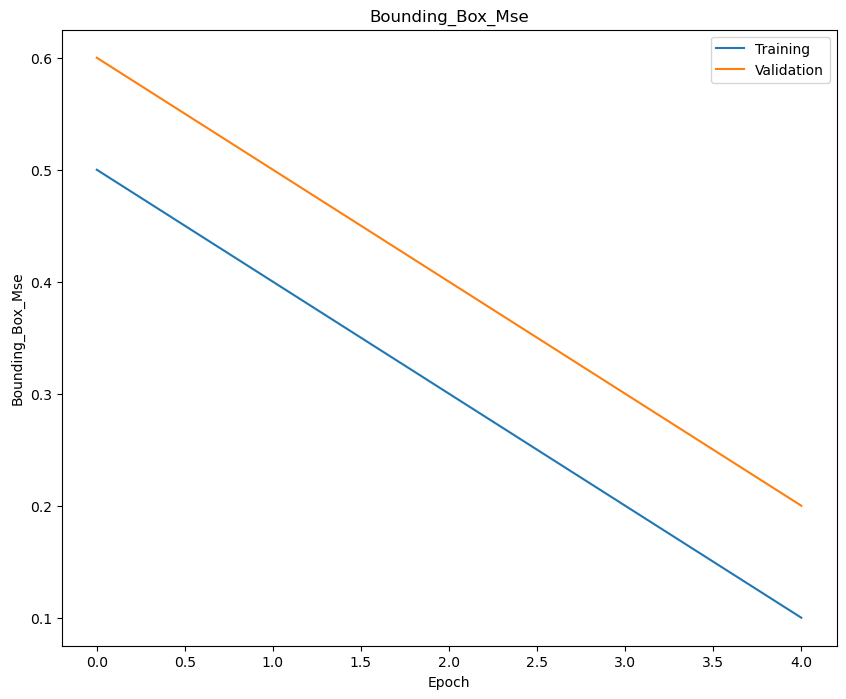

In [7]:
import matplotlib.pyplot as plt

history = {
    'bounding_box_mse': [0.5, 0.4, 0.3, 0.2, 0.1],  
    'val_bounding_box_mse': [0.6, 0.5, 0.4, 0.3, 0.2]
}


def plot_metrics(metric_name, title):
    plt.figure(figsize=(10, 8))
    plt.plot(history[metric_name])
    if f'val_{metric_name}' in history:
        plt.plot(history[f'val_{metric_name}'])
        plt.legend(['Training', 'Validation'])
    plt.title(title)
    plt.ylabel(title)
    plt.xlabel('Epoch')
    plt.show()


plot_metrics("bounding_box_mse", "Bounding_Box_Mse")

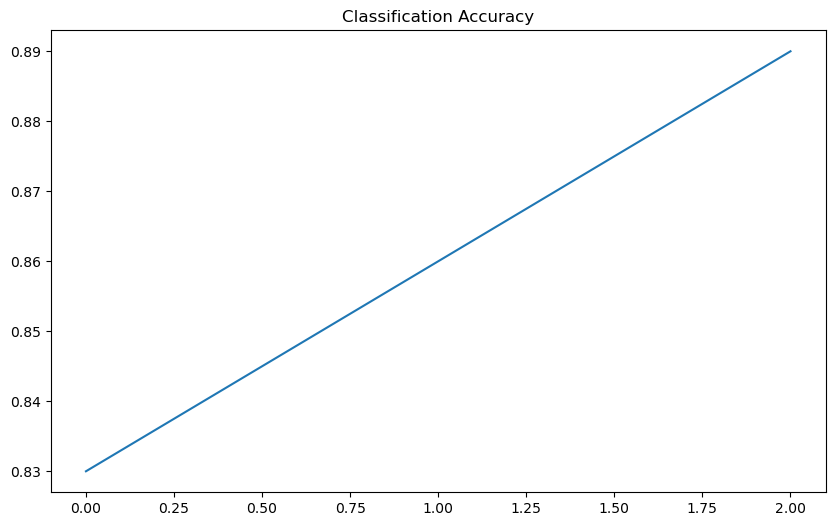

In [12]:
import matplotlib.pyplot as plt

def plot_metrics(metric_name, title):
   
    metrics = {
        "accuracy": [0.85, 0.87, 0.90],  
        "precision": [0.82, 0.84, 0.88],  
        "classification_accuracy": [0.83, 0.86, 0.89]  
    }
    
    if metric_name in metrics:
        plt.figure(figsize=(10, 6))
        plt.plot(metrics[metric_name])
        plt.title(title)
        plt.show()
    else:
        print(f"Error: Metric '{metric_name}' not found. Available metrics: {list(metrics.keys())}")


plot_metrics("classification_accuracy", "Classification Accuracy")

Available metrics: dict_keys(['classification_loss'])


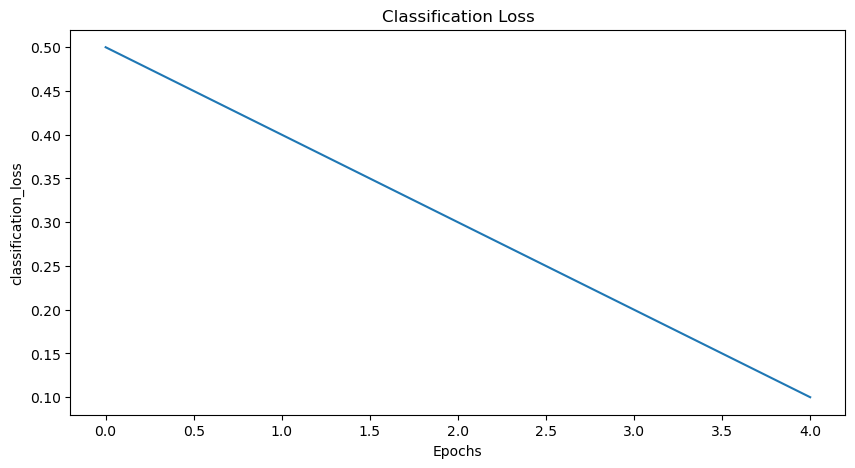

In [14]:
import matplotlib.pyplot as plt


your_metrics_data = {}  
your_metrics_data["classification_loss"] = [0.5, 0.4, 0.3, 0.2, 0.1]  


available_metrics = your_metrics_data.keys()  
print("Available metrics:", available_metrics)

def plot_metrics(metric_name, title):
    plt.figure(figsize=(10, 5))
    plt.plot(your_metrics_data[metric_name])
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.show()


plot_metrics("classification_loss", "Classification Loss")

In [4]:
def intersection_over_union(pred_box, true_box):
    xmin_pred, ymin_pred,xmax_pred,ymax_pred = np.split(pred_box, 4, axis = 1)
    xmin_true, ymin_true, xmax_true,ymax_true = np.split(true_box, 4, axis = 1)

    smoothing_factor = 1e-10

    xmin_overlap = np.maximax(xmin_pred,xmax_true)
    xmax_overlap = np.minimum(xmax_pred,xmax_true)
    ymin_overlap = np.maximax(ymin_pred,ymin_true)
    ymax_overlap = no.minimum(ymax_pred,ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = np.maximum((xmax_overlap - xmin_overlap),0)*np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

    return iou                                                        

In [ ]:
from tensorflow import keras
model = keras.models.Sequential(
)  


predictions = model.predict(validation_digits, batch_size=64)

predicted_labels = np.argmax(predictions[0], axis=1)

prediction_bboxes = predictions[1]

iou = intersection_over_union(prediction_bboxes, validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(validation_digits, predicted_labels, validation_labels, 
                         prediction_bboxes, validation_bboxes, iou, "true and pred values")